Ordered TODO
- Test or revise continuous actions and twohot discretization (don't forget about objective in `train`)
- Vectorize discrete and discretized actions (or at least allow for concise configuration)
- Try evaluation with no random
- Internally rename library
- Implement https://rlgym.org/
- Add timers
- Refactor initialization
- Add mixed precision training, or at least fp16
- Implement distributed
- Implement Plan2Explore
- Add eval as parallel env to training loop, or put in another worker
- Add missing tests
- Vectorize buffer storage and sampling

Novel changes
- TwoHot discretization
- Could add variation output to reward, allowing for trust regions and exploration, maybe an auxiliary loss?

Training stage observations
- Random action
- Overfits to one action
- Then explores slowly from there
- Slower to adapt later on - maybe biased sampling?

Commit list
- `make pre-commit`, ensure tests pass, documentation generates, and no linting errors
- Change versions in `pyproject.toml` and `CITATION.cff` - or find a way around this

Running commands
- Run exported notebook: `conda activate fishyrl && cd examples && python Dreamer.py`
- Run tensorboard: `conda activate fishyrl && tensorboard --logdir ./examples/runs --host 0.0.0.0`
- Host documentation: `cd ./docs/build/html && python -m http.server 8000`
- Convert gif to loop: `ffmpeg -i <INFILE> -loop 0 -filter_complex "[0:v] fps=30,scale=w=480:h=-1:flags=lanczos,split [a][b];[a] palettegen [p];[b][p] paletteuse" <OUTFILE>`

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import math
import os
import re
import time

import torch
import torch.utils.tensorboard

import fishyrl as frl

os.environ['MUJOCO_GL'] = 'egl'  # MuJoCo rendering backend for headless

## Initialization

In [ ]:
# Load config (NOTE: Times are unreliable here, as they were used in varying workloads)
# cfg = frl.utilities.load_config('../examples/configs/CartPole.yaml', '../examples/configs/Dreamer_Small.yaml')  # Load CartPole on top of Dreamer_Small (CartPole-v1_2026-04-10_19-57-31, 23k steps, 1.6h to full-optimal)
# cfg = frl.utilities.load_config('../examples/configs/LunarLander.yaml', '../examples/configs/Dreamer_Small.yaml')  # (BipedalWalker-v3_2026-04-12_08-12-53)
# cfg = frl.utilities.load_config('../examples/configs/BipedalWalker.yaml', '../examples/configs/Dreamer_Small.yaml')  # (LunarLander-v3_2026-04-12_02-59-29)
# cfg = frl.utilities.load_config('../examples/configs/Ant.yaml', '../examples/configs/Dreamer_Small.yaml')  # (Ant-v5_2026-04-12_14-52-06)
# cfg = frl.utilities.load_config('../examples/configs/Hopper.yaml', '../examples/configs/Dreamer_Small.yaml')  # (Hopper-v5_2026-04-13_20-52-25)
# cfg = frl.utilities.load_config('../examples/configs/Reacher.yaml', '../examples/configs/Dreamer_Small.yaml')  # (Reacher-v5_2026-04-14_01-17-55, Not working without reward shaping)
cfg = frl.utilities.load_config('../examples/configs/Walker2D.yaml', '../examples/configs/Dreamer_Small.yaml')  # (Walker2d-v5)
# cfg = frl.utilities.load_config('../examples/configs/Pusher.yaml', '../examples/configs/Dreamer_Small.yaml')  # (Pusher-v5)

# Checkpoint file if not starting from scratch
checkpoint_file = '../examples/runs/Walker2d-v5_2026-04-14_02-55-28/checkpoint_0030000.pt'
start_environment_step = int(re.search(r'checkpoint_(\d+).pt', checkpoint_file).group(1)) if checkpoint_file is not None else 0

# Folder name if manually specified, otherwise auto-generate
folder_name = None

# Define save folder in same folder as checkpoint if loading, otherwise create new folder with timestamp
if folder_name is None:
    if checkpoint_file is not None:
        folder_name = os.path.dirname(checkpoint_file)
    else:
        folder_name = f'{cfg.env.name}_{time.strftime("%Y-%m-%d_%H-%M-%S")}'
        folder_name = f'../examples/runs/{folder_name}'

In [59]:
# Load environment and actions
envs, actions = frl.dreamer.get_environments_and_actions(cfg=cfg)

# Construct models
world_model, actor_critic_model, utility_modules = frl.dreamer.construct_models(
    env_obs_dim=math.prod(envs.observation_space.shape[1:]),  # TODO: Revise for CNN
    env_actions=actions,
    device='cuda',
    cfg=cfg,
)

# Load model and buffer
if checkpoint_file is not None:
    frl.dreamer.load_models(
        path=checkpoint_file,
        world_model=world_model,
        actor_critic_model=actor_critic_model,
        utility_modules=utility_modules,
    )

## Training

In [ ]:
# Tensorboard writer
# TODO: Create folder regardless of writer
writer = torch.utils.tensorboard.SummaryWriter(folder_name)

In [ ]:
# Train the model
frl.dreamer.train_loop(
    envs=envs,
    world_model=world_model,
    actor_critic_model=actor_critic_model,
    utility_modules=utility_modules,
    tensorboard_writer=writer,
    start_environment_step=start_environment_step,
    checkpoint_dir=folder_name,
    cfg=cfg,
)

# # Save model
# frl.dreamer.save_models(
#     path=os.path.join(folder_name, 'model.pth'),
#     world_model=world_model,
#     actor_critic_model=actor_critic_model,
#     utility_modules=utility_modules,
# )

In [ ]:
# Close tensorboard writer
writer.close()

## Evaluation

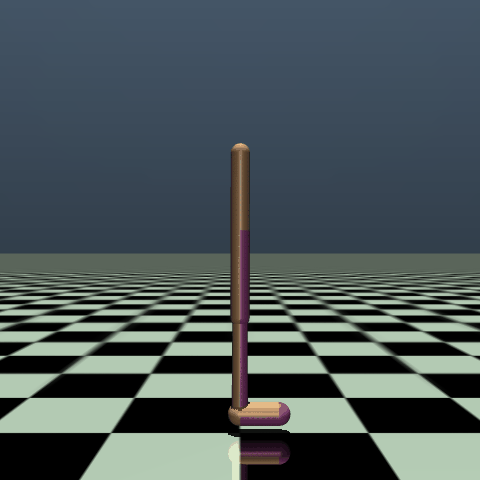

In [60]:
# Evaluate the model
frames, fps = frl.dreamer.evaluate(
    env_name=cfg.env.name,
    world_model=world_model,
    actor_critic_model=actor_critic_model,
    seed=42,
)

# Save video to file
path = f'./images/{cfg.name}_{start_environment_step/1000:.0f}k.gif'
frl.utilities.export_gif(path, frames, fps=fps)

# Display video locally
from IPython.display import Image  # noqa: E402, I001
Image(filename=path)